# Pendulum - Action angle coordinates

In [54]:
# In the notebook I will ask you to code stuff, do 2 separate cell for computing quantities (the stuff that I want people to understant or read) and plotting figure (which will be hidden)

In [55]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.special import ellipj, ellipk, ellipe, ellipkinc
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["figure.dpi"] = 72          # animations are embedded frame by frame, keep them light


$$
\ddot \theta = -\sin(\theta) \to \dot \theta = \omega, \dot \omega = - \sin(\theta)
$$

That's the pendulum equation (with $m = g = L = 1$), we can integrate it numerically to get trajectories from an initial state $(\theta_0, \dot\theta_0)$. We simulate **four** of them once here, released from rest at four different angles, and everything after that is read off those same four trajectories.


In [56]:
def pendulum(x):
    """x = (..., 2) states (theta, thetadot)  ->  d/dt x = (thetadot, -sin(theta))"""
    theta, thetadot = x[..., 0], x[..., 1]
    return np.stack([thetadot, -np.sin(theta)], -1)


def integrate(x0, t):
    """odeint works on a flat state, so we ravel the batch of initial conditions on the
    way in and reshape on the way out -> (time, n_traj, 2)."""
    x0 = np.asarray(x0, float)
    flat = odeint(lambda x, _: pendulum(x.reshape(-1, 2)).ravel(), x0.ravel(), t,
                  rtol=1e-10, atol=1e-12)
    return flat.reshape(len(t), *x0.shape)


# four swings, all released from rest, from a small one to one that nearly stalls
# at the top. This is the only simulation of the notebook, the rest is diagnostics.
theta0 = np.array([0.6, 1.4, 2.2, 2.8])
x0 = np.stack([theta0, np.zeros_like(theta0)], -1)
t = np.linspace(0, 20, 401)

traj = integrate(x0, t)          # (time, traj, 2)
traj.shape


(401, 4, 2)

In [57]:
COLORS = [plt.get_cmap("viridis")(v) for v in np.linspace(.15, .85, len(theta0))]
STRIDE = 5          # animate every 5th time step


def pendulum_animation(t, theta, rows, colors=None, stride=STRIDE, interval=60):
    """Left: the pendulums drawn in 2d.  Right: one panel per signal, where `rows` is a
    list of (label, array of shape (time, n_traj)), with a cursor following the animation."""
    colors = COLORS if colors is None else colors
    n = theta.shape[1]
    fig = plt.figure(figsize=(11, 1.6 * len(rows) + 1.1))
    gs = fig.add_gridspec(len(rows), 2, width_ratios=[1, 1.7], hspace=.15, wspace=.22)

    ax = fig.add_subplot(gs[:, 0])
    ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), xticks=[], yticks=[], title="the pendulum")
    ax.set_aspect("equal")
    ax.plot(0, 0, "k+", ms=8)
    rods = [ax.plot([], [], "-", color=colors[i], lw=1.5)[0] for i in range(n)]
    bobs = [ax.plot([], [], "o", color=colors[i], ms=11)[0] for i in range(n)]

    cursors, dots, axes = [], [], []
    for r, (label, y) in enumerate(rows):
        a = fig.add_subplot(gs[r, 1])
        for i in range(n):
            a.plot(t, y[:, i], color=colors[i], lw=1.2)
            dots.append((a.plot([], [], "o", color=colors[i], ms=6)[0], y[:, i]))
        cursors.append(a.axvline(t[0], color="k", lw=.8, alpha=.5))
        a.set(ylabel=label, xlim=(t[0], t[-1]))
        a.tick_params(labelbottom=(r == len(rows) - 1))
        if r == len(rows) - 1:
            a.set_xlabel("t")
        axes.append(a)

    def update(f):
        for i, (rod, bob) in enumerate(zip(rods, bobs)):
            px, py = np.sin(theta[f, i]), -np.cos(theta[f, i])
            rod.set_data([0, px], [0, py])
            bob.set_data([px], [py])
        for c in cursors:
            c.set_xdata([t[f], t[f]])
        for dot, y in dots:
            dot.set_data([t[f]], [y[f]])
        return rods + bobs + cursors + [d for d, _ in dots]

    anim = FuncAnimation(fig, update, frames=range(0, len(t), stride),
                         interval=interval, blit=False)
    plt.close(fig)
    return anim, axes


anim, _ = pendulum_animation(t, traj[..., 0],
                             [(r"$\theta$", traj[..., 0]),
                              (r"$\dot\theta$", traj[..., 1])])
HTML(anim.to_jshtml())


## Energy and period

Interesting quantity we can derive first is the energy of the system ($H$)

$$
H = \underbrace{\tfrac{1}{2}\dot\theta^2}_{\text{kinetic}} + \underbrace{1 - \cos\theta}_{\text{potential}} \in [0, 2)
$$

The energy is dependent of $\theta$ and $\dot \theta$ and as the system is conservative is going to be preserved through all the trajectory.

The period, which indicates the time that takes for the pendulum to do a full revolution is also a property of the trajectory. We can compute with the elliptic integral of the first kind :

$$
T(k) = 4 * F(\tfrac{\pi}{2}, k) \text{ with : } k = \sqrt{H/2} \text{ and } F(\varphi, k) = \int_0^{\varphi} \frac{dt}{\sqrt{1 - k^2 \sin^2 t}}
$$

$F(\tfrac{\pi}{2}, k) = K(k)$ is the *complete* elliptic integral of the first kind, which is what `scipy.special.ellipk` gives — careful, scipy takes the parameter $m = k^2$, so `ellipk(H / 2)`.

So from a point we get the energy of the system and from the energy we get the period of this system.


In [88]:
def energy(x):
    """H = 1/2 thetadot^2 + 1 - cos(theta), the kinetic plus the potential term."""
    theta, thetadot = x[..., 0], x[..., 1]
    return 0.5 * thetadot ** 2 + 1 - np.cos(theta)


def period(H):
    """T = 4 F(pi/2, k) = 4 K(k) with k = sqrt(H / 2). scipy's ellipk takes m = k ** 2."""
    return 4 * ellipk(np.asarray(H) / 2)


H = energy(traj)            # (time, traj), and it should not depend on time at all

In [89]:
anim, axes = pendulum_animation(t, traj[..., 0],
                                [(r"$\theta$", traj[..., 0]),
                                 (r"$\dot\theta$", traj[..., 1]),
                                 (r"$H$", H)])
axes[-1].set_ylim(0, 2.05)          # full range of H, so its flatness is honest
HTML(anim.to_jshtml())


In [60]:
fig = plt.figure(figsize=(11, 4.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=.25)

ax = fig.add_subplot(gs[0, 0])
ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), xticks=[], yticks=[], title="four energy levels")
ax.set_aspect("equal")
ax.plot(0, 0, "k+", ms=8)
rods = [ax.plot([], [], "-", color=c, lw=1.5)[0] for c in COLORS]
bobs = [ax.plot([], [], "o", color=c, ms=11)[0] for c in COLORS]

axc = fig.add_subplot(gs[0, 1])
Hg = np.linspace(1e-4, 1.9999, 400)
axc.plot(Hg, period(Hg), "k-", lw=1.2, alpha=.6)
axc.axhline(2 * np.pi, color="k", ls=":", lw=.8)
axc.annotate(r"$2\pi$, the small oscillation limit", (0.02, 2 * np.pi), fontsize=8, va="bottom")
marks = [axc.plot([h], [T], "o", color=c, ms=12)[0] for h, T, c in zip(H0, T0, COLORS)]
for h, T in zip(H0, T0):
    axc.annotate(f"T = {T:.2f}", (h, T), textcoords="offset points", xytext=(9, -3), fontsize=8)
axc.set(xlabel="energy $H$", ylabel="period $T$", ylim=(5.5, 16),
        title="one energy level, one period")


def update(f):
    for i, (rod, bob) in enumerate(zip(rods, bobs)):
        px, py = np.sin(traj[f, i, 0]), -np.cos(traj[f, i, 0])
        rod.set_data([0, px], [0, py])
        bob.set_data([px], [py])
    # each marker blinks at its own period, in sync with its pendulum
    for i, m in enumerate(marks):
        m.set_alpha(.35 + .65 * (.5 + .5 * np.cos(2 * np.pi * t[f] / T0[i])))
    return rods + bobs + marks


anim = FuncAnimation(fig, update, frames=range(0, len(t), STRIDE), interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())


KeyboardInterrupt: 

## Action - Angle

### The phase-state 

Now we saw that each trajectory is going to keep a constant energy and go around with it's period we can draw it's trajectory for a full period. This will link several points of the physical space together ! Those points share the same energy and then will always belong to the same trajectories. 

In [ ]:
def level_set(H, n=300):
    """The H level set of the phase space: thetadot = +- sqrt(2 (H - 1 + cos theta)),
    walked out along the top branch and back along the bottom one, so the curve closes."""
    th = np.linspace(-np.arccos(1 - H), np.arccos(1 - H), n)
    v = np.sqrt(np.clip(2 * (H - 1 + np.cos(th)), 0, None))
    return np.concatenate([th, th[::-1]]), np.concatenate([v, -v[::-1]])


stride = 7          # four trajectories run one after the other here, so animate coarser
dt = t[1] - t[0]

fig = plt.figure(figsize=(11, 4.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=.25)

ax = fig.add_subplot(gs[0, 0])
ax.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), xticks=[], yticks=[], title="one swing at a time")
ax.set_aspect("equal")
ax.plot(0, 0, "k+", ms=8)
rod, = ax.plot([], [], "-", lw=1.5)
bob, = ax.plot([], [], "o", ms=11)

axp = fig.add_subplot(gs[0, 1])
axp.plot(*level_set(1.9999), "k--", lw=1, alpha=.5)
axp.annotate("separatrix, $H = 2$", (0, 2), fontsize=8, ha="center", va="bottom")
fills = [axp.plot([], [], "-", color="0.75", lw=.7, zorder=0)[0] for _ in range(24)]
fill_H = np.linspace(0.05, 1.95, len(fills))
curves = [axp.plot([], [], "-", color=c, lw=1.6)[0] for c in COLORS]
points = [axp.plot([], [], "o", color=c, ms=8)[0] for c in COLORS]
axp.set(xlim=(-np.pi, np.pi), ylim=(-2.35, 2.35), xlabel=r"$\theta$", ylabel=r"$\dot\theta$",
        title="phase space: one trajectory, one closed curve")

# swing each pendulum for exactly one period, tracing its curve, then keep the curve and
# move to the next one. Once the four are drawn, fill in the levels in between.
frames = [("run", i, j) for i in range(len(theta0))
          for j in range(0, int(T0[i] / dt) + 2, stride)]
frames += [("fill", c, 0) for c in range(len(fills))]
frames += [("fill", len(fills) - 1, 0)] * 8          # hold on the finished picture


def update(frame):
    kind, a, b = frame
    if kind == "run":
        i, j = a, min(b, len(t) - 1)
        rod.set_data([0, np.sin(traj[j, i, 0])], [0, -np.cos(traj[j, i, 0])])
        bob.set_data([np.sin(traj[j, i, 0])], [-np.cos(traj[j, i, 0])])
        rod.set_color(COLORS[i])
        bob.set_color(COLORS[i])
        curves[i].set_data(traj[:j + 1, i, 0], traj[:j + 1, i, 1])
        points[i].set_data([traj[j, i, 0]], [traj[j, i, 1]])
    else:
        for p in points:          # freeze the last pendulum, drop the moving dots
            p.set_data([], [])
        for c in range(a + 1):
            fills[c].set_data(*level_set(fill_H[c]))
    return [rod, bob] + curves + points + fills


anim = FuncAnimation(fig, update, frames=frames, interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())


### Navigate in the phase space 

![](images/aa-pipe.png)


#### From state to action-angle 

The idea of the action-angle coordinates is that we can represent our position in the phase space from the ation $I$ which determines on which level of energy you are on and angle $\alpha$ which is the point you are on the phase space. During one period we do a full rotation on the phase space level-set. 

**Action.**
$$
I = \frac{8}{\pi}\Big[E(k) - (1-k^2)K(k)\Big] \in \left[0, \tfrac{8}{\pi}\right)
$$

**Angle.** Let $\varphi$ be the Jacobi amplitude, recovered from the state by
$$
\alpha = \frac{\pi}{2K(k)}\, F(\varphi, k) \text{ with }\varphi = \mathrm{atan2}\!\left(\sin(\theta/2),\ \dot\theta/2\right)
$$

Where $E$ is the elliptic integral of the second kind : 

$$
E(k) = \int_0^{\pi/2} \sqrt{1 - k^2 \sin^2 t}\ dt
$$

**To summarize :** from the state $(\theta, \dot \theta)$ we get the energy $H$ and can derive $I$ (which is constant for the full trajectory of states) and $\alpha$ which is varying linearly through time. 

In [66]:
def action(k):
    """I(k) = 8/pi[E(k) - (1 - k^2)K(k)]"""
    m = k ** 2                      # scipy takes the parameter m = k^2, as for ellipk above
    return 8 / np.pi * (ellipe(m) - (1 - m) * ellipk(m))


def angle(k, x):
    """
     alpha(k) = [pi / (2 * K(k))] * F(phi(theta, thetadot), k)
    """
    m = k ** 2
    phi = np.arctan2(np.sin(x[..., 0] / 2), x[..., 1] / 2)
    return np.pi / (2 * ellipk(m)) * ellipkinc(phi, m)


In [67]:
traj_H = energy(traj) # (T, n_traj)
traj_k = np.sqrt(traj_H / 2)
traj_I = action(traj_k)
traj_alpha = angle(traj_k, traj)

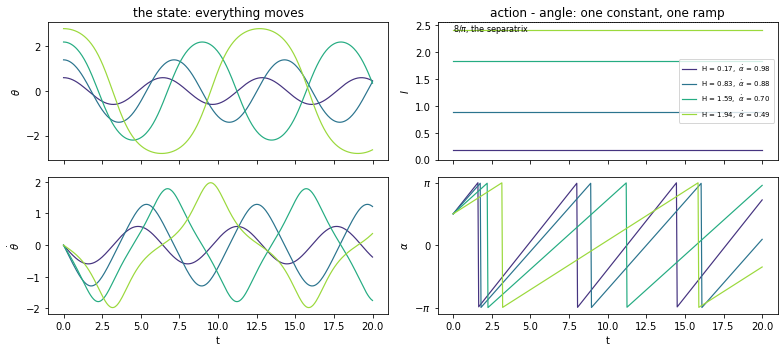

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
rows = [(axs[0, 0], r"$\theta$", traj[..., 0]), (axs[1, 0], r"$\dot\theta$", traj[..., 1]),
        (axs[0, 1], r"$I$", traj_I), (axs[1, 1], r"$\alpha$", traj_alpha)]
for a, label, y in rows:
    for i in range(len(theta0)):
        a.plot(t, y[:, i], color=COLORS[i], lw=1.2,
               label=(f"H = {H0[i]:.2f},  " r"$\dot\alpha$ = " f"{2 * np.pi / T0[i]:.2f}"
                      if a is axs[0, 1] else None))
    a.set_ylabel(label)
axs[0, 0].set_title("the state: everything moves")
axs[0, 1].set_title("action - angle: one constant, one ramp")
axs[0, 1].set_ylim(0, 8 / np.pi)                    # the whole range of I, so flat is flat
axs[0, 1].axhline(8 / np.pi, color="k", ls=":", lw=.8)
axs[0, 1].annotate(r"$8/\pi$, the separatrix", (t[0], 8 / np.pi), fontsize=8, va="top")
axs[0, 1].legend(fontsize=7, loc="center right")
axs[1, 1].set(yticks=[-np.pi, 0, np.pi], yticklabels=[r"$-\pi$", "0", r"$\pi$"])
for a in axs[1]:
    a.set_xlabel("t")
fig.tight_layout()
plt.show()


As we can see what is super interesting is that we get a representation of the trajectory where we de-untangled the "static / energy" and the dynamic part : when we have done the projection only the angle is moving during integration. What is also fun is that by injecting some energy into the representation ($\hat I = I + \eps$) we have a new trajectory at the same relative time (the angle will represent the time in the period, like if you are at $\alpha = \pi$ you will be also at the half of the period on the new trajectory) and get a fully new trajectory. 

#### From action-angle to state

Now the interesting part ! We can go back from this action / angle representation to the real physical space !
  
Basically it boils down to two inversions, the second one has an analytic solution implemented in scipy but the first one
doesn't, but it has a few characteristics :

As we choosen to represent the Libration regime, the pendulum has a turning point $\theta_{max} \in [0; \pi[$, and as it 
corresponds to an extremal point we also have $\dot \theta = 0$ there (the pendulum is turning around) and thus $H(\theta, 
\dot \theta) = \frac{1}{2}\dot \theta^2 + 1 -\cos(\theta) = 1 - \cos(\theta_{max}) \in [0; 2[$

Thus :

- $m = \frac{H}{2} \in [0; 1[$
- $I(0) = \frac{8}{\pi}(E(0) - K(0)) = 0$ and   $I(1) = \frac{8}{\pi}(E(1)) = \frac{8}{\pi}$ (looking at the definition of
$K$ and $E$) so $I(m) \in [0; \frac{8}{\pi}[$
- $I'(m) = \frac{4}{\pi} K(m) \gt 0$ so $I$ is strictly increasing

So to find $m$ such as $I(m) = a \in [0; \frac{8}{\pi}[$ we just need to find the point where $I(m) - a = 0$, we are
exactly in the setup where we can use  `brentq` from scipy (change of sign and continuous), and because it's monotonic we know we find the unique root !

In [81]:
from scipy.optimize import brentq


def m_from_I(I):
    """Invert I(m) = 8/pi[E(m) - (1 - m)K(m)].
    """
    I = np.asarray(I)
    m = [brentq(lambda mm: action(np.sqrt(mm)) - a, 0.0, 1 - 1e-15, xtol=1e-14)
         for a in I.ravel()]
    return np.array(m).reshape(I.shape)


def phi_from_F_m(F, m):
    """Invert F(phi, m) in its first argument at fixed m: the Jacobi amplitude
    phi = am(F | m). Closed form, no solve.
    """
    return ellipj(F, m)[3]


def state_from_phi_H(phi, H):
    """(phi, H) -> (theta, thetadot), the inverse of the atan2 in `angle` above.
    """
    return np.stack([2 * np.arcsin(np.sqrt(H / 2) * np.sin(phi)),
                     np.sqrt(2 * H) * np.cos(phi)], -1)

In [ ]:
r_traj_m = m_from_I(traj_I)                              # I   -> m,   the numerical one
r_traj_F = traj_alpha * ellipk(r_traj_m) * 2 / np.pi     # alpha -> F, just a rescaling
r_traj_phi = phi_from_F_m(r_traj_F, r_traj_m)            # F   -> phi, the analytic one
r_traj = state_from_phi_H(r_traj_phi, 2 * r_traj_m)      # (phi, H = 2m) -> state

m     recovered to 1.1e-15
state recovered to 5.4e-15


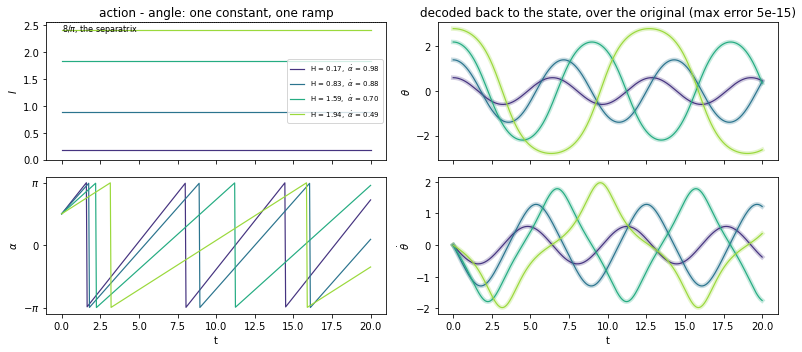

In [87]:
fig, axs = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
rows = [(axs[0, 0], r"$I$", traj_I), (axs[1, 0], r"$\alpha$", traj_alpha),
        (axs[0, 1], r"$\theta$", r_traj[..., 0]), (axs[1, 1], r"$\dot\theta$", r_traj[..., 1])]
for a, label, y in rows:
    for i in range(len(theta0)):
        a.plot(t, y[:, i], color=COLORS[i], lw=1.2,
               label=(f"H = {H0[i]:.2f},  " r"$\dot\alpha$ = " f"{2 * np.pi / T0[i]:.2f}"
                      if a is axs[0, 0] else None))
    a.set_ylabel(label)

# the original state drawn underneath the decoded one, thick and faded: the thin line on
# top is the round trip, so any mismatch at all would show up as a fringe of colour
for a, y in [(axs[0, 1], traj[..., 0]), (axs[1, 1], traj[..., 1])]:
    for i in range(len(theta0)):
        a.plot(t, y[:, i], color=COLORS[i], lw=4.5, alpha=.25, zorder=0)

axs[0, 0].set_title("action - angle: one constant, one ramp")
axs[0, 1].set_title("decoded back to the state, over the original "
                    f"(max error {np.abs(r_traj - traj).max():.0e})")
axs[0, 0].set_ylim(0, 8 / np.pi)                    # the whole range of I, so flat is flat
axs[0, 0].axhline(8 / np.pi, color="k", ls=":", lw=.8)
axs[0, 0].annotate(r"$8/\pi$, the separatrix", (t[0], 8 / np.pi), fontsize=8, va="top")
axs[0, 0].legend(fontsize=7, loc="center right")
axs[1, 0].set(yticks=[-np.pi, 0, np.pi], yticklabels=[r"$-\pi$", "0", r"$\pi$"])
for a in axs[1]:
    a.set_xlabel("t")
fig.tight_layout()
plt.show()

In [96]:
def encoder(state) : 
    """
        state (T, n_traj, 2) -> latent (T, n_traj, 2)
    """
    traj_H = energy(state) # (T, n_traj)
    traj_k = np.sqrt(traj_H / 2)
    traj_I = action(traj_k)
    traj_alpha = angle(traj_k, traj)
    return np.stack([traj_I, traj_alpha], axis=-1)

In [ ]:
encoder(traj)

(401, 4, 2)

In [99]:
def decoder(latent) :
    """
         latent (T, n_traj, 2) -> state (T, n_traj, 2)
    """
    traj_I, traj_alpha = latent[..., 0], latent[..., 1]
    r_traj_m = m_from_I(traj_I)                              # I   -> m,   the numerical one
    r_traj_F = traj_alpha * ellipk(r_traj_m) * 2 / np.pi     # alpha -> F, just a rescaling
    r_traj_phi = phi_from_F_m(r_traj_F, r_traj_m)            # F   -> phi, the analytic one
    r_traj = state_from_phi_H(r_traj_phi, 2 * r_traj_m)      # (phi, H = 2m) -> state
    return r_traj

In [102]:
np.allclose(decoder(encoder(traj)), traj)

True